In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
dataset = pd.read_csv(r"C:\Users\nabha\OneDrive\Desktop\Projects\DecodeLabsP2\Dataset for Data Analytics.csv")
dataset.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [11]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   str    
 1   Date             1200 non-null   str    
 2   CustomerID       1200 non-null   str    
 3   Product          1200 non-null   str    
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   str    
 7   PaymentMethod    1200 non-null   str    
 8   OrderStatus      1200 non-null   str    
 9   TrackingNumber   1200 non-null   str    
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    str    
 12  ReferralSource   1200 non-null   str    
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), str(10)
memory usage: 131.4 KB


In [12]:
dataset.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [14]:
dataset.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [33]:
dataset["CouponCode"] = dataset["CouponCode"].fillna("No Coupon")

In [56]:
dataset.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [21]:
dataset.groupby("Product")["TotalPrice"].sum()

Product
Chair      195620.11
Desk       167459.93
Laptop     192126.56
Monitor    175651.41
Phone      151722.39
Printer    195612.61
Tablet     186568.95
Name: TotalPrice, dtype: float64

In [22]:
dataset.groupby("ShippingAddress")["TotalPrice"].sum().sort_values(ascending=False)

ShippingAddress
533 Main St    7753.73
558 Main St    7527.40
740 Main St    6761.84
747 Main St    6700.24
811 Main St    6668.36
                ...   
595 Main St      44.35
215 Main St      38.49
556 Main St      36.65
482 Main St      21.19
441 Main St      18.20
Name: TotalPrice, Length: 655, dtype: float64

In [27]:
dataset["Date"] = pd.to_datetime(dataset["Date"])

In [30]:
dataset.groupby(dataset["Date"].dt.month_name())["TotalPrice"].sum()

Date
April        109186.05
August        86343.21
December      82540.50
February     112344.78
January      124313.23
July          85784.64
June         170616.13
March        123840.93
May          135142.59
November      75493.43
October       89834.82
September     69321.65
Name: TotalPrice, dtype: float64

In [35]:
dataset["ReferralSource"].value_counts()

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

In [50]:
dataset.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False)

CustomerID
C38840    5723.23
C57276    3456.40
C67260    3390.80
C13877    3384.90
C18404    3370.20
           ...   
C88174      18.20
C49726      17.98
C14983      17.24
C98276      14.06
C32570      11.39
Name: TotalPrice, Length: 1189, dtype: float64

In [63]:
dataset["Product"].value_counts()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

In [73]:
dataset[dataset["Quantity"] < 0 ]

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice


Outlier Detection


In [77]:
Q1 = dataset["TotalPrice"].quantile(0.25)
Q3 = dataset["TotalPrice"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = dataset[ (dataset["TotalPrice"] < lower) | (dataset["TotalPrice"] > upper)]
outliers

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,No Coupon,Facebook,3384.90
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,No Coupon,Facebook,3390.95


Exploitary Data Analysis

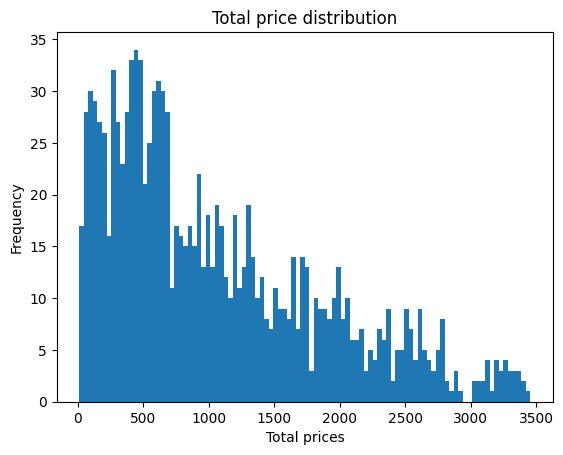

In [86]:
plt.hist(dataset["TotalPrice"],bins=100)
plt.xlabel("Total prices")
plt.ylabel("Frequency")
plt.title("Total price distribution")

plt.show()

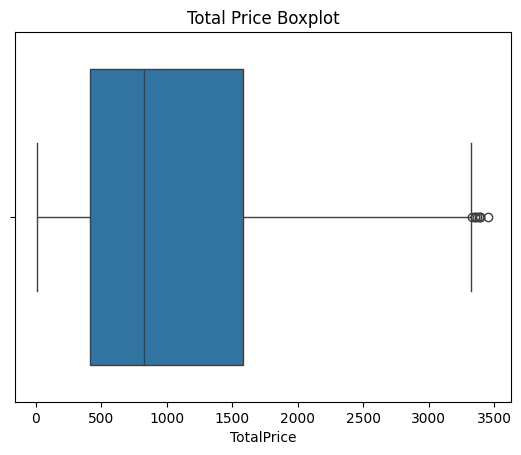

In [89]:
sns.boxplot(x = dataset["TotalPrice"])
plt.title("Total Price Boxplot")

plt.show()

In [92]:
dataset.sort_values(by="TotalPrice",ascending=False)[["Product","Quantity","TotalPrice"]].head(10)

,Product,Quantity,TotalPrice
789,Tablet,5,3456.40
1122,Monitor,5,3390.95
632,Laptop,5,3390.80
469,Chair,5,3384.90
328,Tablet,5,3370.20
107,Printer,5,3353.75
326,Laptop,5,3352.40
1065,Printer,5,3334.00
1031,Phone,5,3322.55
463,Laptop,5,3313.90


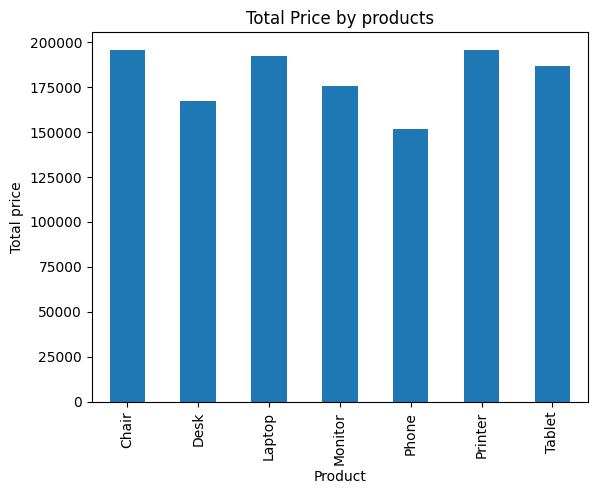

In [94]:
cat_sales = dataset.groupby("Product")["TotalPrice"].sum()
cat_sales.plot(kind="bar")
plt.ylabel("Total price")
plt.title("Total Price by products")

plt.show()

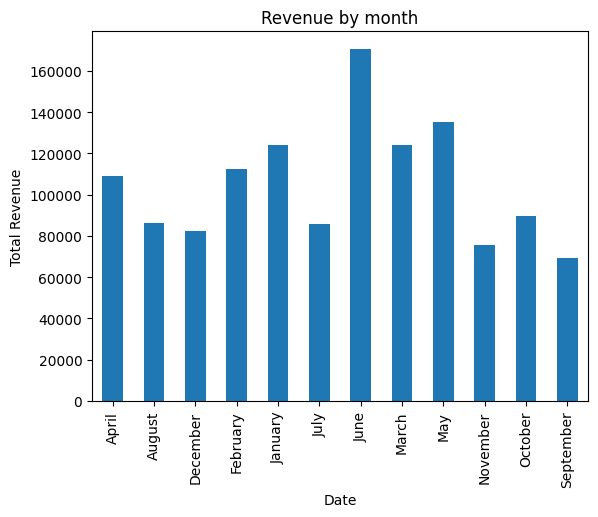

In [96]:
monthly_sales = dataset.groupby(dataset["Date"].dt.month_name())["TotalPrice"].sum()
monthly_sales.plot(kind="bar")
plt.ylabel("Total Revenue")
plt.title("Revenue by month")

plt.show()

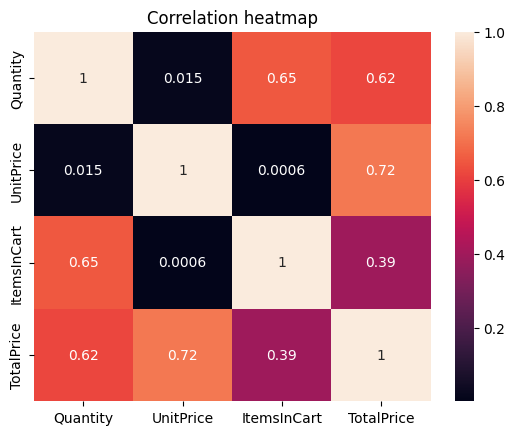

In [98]:
corr = dataset.corr(numeric_only=True)
sns.heatmap(corr,annot=True)
plt.title("Correlation heatmap")

plt.show()